# Experiment: codex

## 0 Setup

This section prepares a reproducible starting point for the benchmark pipeline.
- Review the variable dictionary
- Set global seed to 42
- Verify required files exist

Conventions:
- Use only relative paths
- Keep `random_state=42` for all later randomized operations
- Execute notebook top-to-bottom without manual intervention

In [1]:
# Read the variable dictionary (do not load the data file in Step 0)
from pathlib import Path

DICT_PATH = Path('../../data/participation_2024-25_data_dictionary_cleaned.txt')

with DICT_PATH.open('r', encoding='utf-8') as f:
    dictionary_text = f.read()

print(dictionary_text)

UK Data Archive Data Dictionary

File-level information:

File Name = 		participation_2024-25_annual_data_open
Number of cases = 	34378


Variable-level information:

Pos. = 1,175	Variable = CARTS_NET	Variable label = In the last 12 months, engaged (attended OR participated) with the arts physically
This variable is    numeric, the SPSS measurement level is NOMINAL
SPSS user missing values = -1.7976931348623155e+308 thru -1.0
	Value label information for CARTS_NET
	Value = -3.0	Label = Not applicable
	Value = 1.0	Label = Yes
	Value = 2.0	Label = No
	Value = 3.0	Label = No & Missing

Pos. = 1,308	Variable = AGEBAND	Variable label = Respondent age band (ALL)
This variable is    numeric, the SPSS measurement level is SCALE
	Value label information for AGEBAND
	Value = -3.0	Label = Not Applicable
	Value = 1.0	Label = 16 to 19
	Value = 2.0	Label = 20 to 24
	Value = 3.0	Label = 25 to 29
	Value = 4.0	Label = 30 to 34
	Value = 5.0	Label = 35 to 39
	Value = 6.0	Label = 40 to 44
	Value = 7.0	Lab

In [2]:
# Set global random seed for reproducibility
import random
import numpy as np

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f'Random seed set to {RANDOM_STATE}')

Random seed set to 42


In [3]:
# Verify required files are present via relative paths
DATA_PATH = Path('../../data/participation_2024-25_experiment.tab')

required_files = {
    'Variable dictionary': DICT_PATH,
    'Data file': DATA_PATH,
}

for name, path in required_files.items():
    exists = path.exists()
    print(f'{name}: {path} -> {"FOUND" if exists else "MISSING"}')
    assert exists, f'{name} not found at {path}'

Variable dictionary: ../../data/participation_2024-25_data_dictionary_cleaned.txt -> FOUND
Data file: ../../data/participation_2024-25_experiment.tab -> FOUND


# 1 Dataset Ingestion + Schema Checks + Problem Definition
## 1.1 Dataset ingestion and schema checks
In this subsection, I load the benchmark dataset, verify the required variables, and run schema checks that are important before any cleaning or modelling.

Checks performed:
- dataset shape (rows and columns)
- required-variable presence
- duplicate column names
- dtype overview
- observed-value range checks against expected coded values

In [4]:
import pandas as pd

# Load dataset for schema inspection
RAW_DATA_PATH = Path('../../data/participation_2024-25_experiment.tab')
participation_raw = pd.read_csv(RAW_DATA_PATH, sep='\t')

required_vars = [
    'CARTS_NET', 'AGEBAND', 'SEX', 'QWORK', 'EDUCAT3',
    'FINHARD', 'CINTOFT', 'gor', 'rur11cat', 'CHILDHH', 'COHAB'
]

print(f'participation_raw shape: {participation_raw.shape[0]} rows x {participation_raw.shape[1]} columns')
print('\nRequired-variable presence check:')
missing_vars = [c for c in required_vars if c not in participation_raw.columns]
if missing_vars:
    print('Missing required variables:', missing_vars)
else:
    print('All required variables are present.')

print('\nDuplicate column name check:')
print('Has duplicate columns:', bool(participation_raw.columns.duplicated().any()))

print('\nDtype overview for required variables:')
print(participation_raw[required_vars].dtypes.to_string())

# Expected coding sets from the variable dictionary
expected_codes = {
    'CARTS_NET': {1, 2, 3, -3},
    'AGEBAND': set(range(1, 16)) | {-3, 997},
    'SEX': {1, 2, -5, -4, -3, 997},
    'QWORK': {1, 2, 3, 4, 5, 6, 8, 9, 10, -5, -4, -3, 997, 999},
    'EDUCAT3': {1, 2, -5, -4, -3, 997, 999},
    'FINHARD': {1, 2, 3, 4, 5, -5, -4, -3, 997},
    'CINTOFT': {1, 2, 3, 4, 5, -5, -4, -3},
    'gor': {1, 2, 3, 4, 5, 6, 7, 8, 9},
    'rur11cat': {1, 2},
    'CHILDHH': {0, 1, 2, 3, 4, -6, -5, -4, -3, 997},
    'COHAB': {1, 2, -5, -4, -3, 997},
}

schema_rows = []
for col in required_vars:
    observed = set(participation_raw[col].dropna().unique())
    unexpected = sorted(observed - expected_codes[col])
    schema_rows.append({
        'variable': col,
        'n_unique_observed': participation_raw[col].nunique(dropna=False),
        'min_observed': participation_raw[col].min(),
        'max_observed': participation_raw[col].max(),
        'unexpected_codes': unexpected,
    })

schema_summary = pd.DataFrame(schema_rows)
print('\nSchema check summary:')
display(schema_summary)

if (schema_summary['unexpected_codes'].map(len) > 0).any():
    print('Warning: some variables have unexpected observed codes.')
else:
    print('No unexpected observed codes found for required variables.')

participation_raw shape: 34378 rows x 11 columns

Required-variable presence check:
All required variables are present.

Duplicate column name check:
Has duplicate columns: False

Dtype overview for required variables:
CARTS_NET    int64
AGEBAND      int64
SEX          int64
QWORK        int64
EDUCAT3      int64
FINHARD      int64
CINTOFT      int64
gor          int64
rur11cat     int64
CHILDHH      int64
COHAB        int64

Schema check summary:


,variable,n_unique_observed,min_observed,max_observed,unexpected_codes
0,CARTS_NET,3,1,3,[]
1,AGEBAND,17,-3,997,[]
2,SEX,5,-5,997,[]
3,QWORK,14,-5,999,[]
4,EDUCAT3,7,-5,999,[]
5,FINHARD,9,-5,997,[]
6,CINTOFT,8,-5,5,[]
7,gor,9,1,9,[]
8,rur11cat,2,1,2,[]
9,CHILDHH,7,-5,4,[]


No unexpected observed codes found for required variables.


## 1.2 Problem definition
This is a **binary classification** task: predict whether a respondent engaged with the arts physically in the last 12 months.

Task framing:
- Policy question: identify people with likely **under-engagement** (non-participation), where non-participation can be socially patterned rather than purely individual preference.
- Target variable: `CARTS_NET`
- Feature variables: `AGEBAND, SEX, QWORK, EDUCAT3, FINHARD, CINTOFT, gor, rur11cat, CHILDHH, COHAB`
- Later target cleaning rule: rows where `CARTS_NET` is `-3` or `3` will be dropped in Step 2 (treated as missing/non-usable target values). They are **not dropped in Step 1**.

| Variable | Role | Description | Key coded values |
|---|---|---|---|
| `CARTS_NET` | Target | Engaged with arts physically in last 12 months | `1=Yes`, `2=No`, `3=No & Missing`, `-3=Not applicable` |
| `AGEBAND` | Feature | Respondent age band | `1-15` age bands, `997=Prefer not to say`, `-3=Not Applicable` |
| `SEX` | Feature | Respondent gender | `1=Female`, `2=Male`, `997=Prefer not to say`, negatives = non-response/admin codes |
| `QWORK` | Feature | Current working status | `1,2,3,4,5,6,8,9,10` valid statuses; `997/999` and negatives are non-informative |
| `EDUCAT3` | Feature | Highest qualification | `1=Degree+`, `2=Other`, `997/999` and negatives are non-informative |
| `FINHARD` | Feature | Financial management difficulty | `1-5` valid scale; `997` and negatives are non-informative |
| `CINTOFT` | Feature | Internet-use frequency | `1-5` valid frequency; negatives are non-informative |
| `gor` | Feature | Region (GOR) | `1-9` regions |
| `rur11cat` | Feature | Rural/Urban (2011 Census) | `1=Rural`, `2=Urban` |
| `CHILDHH` | Feature | Number of children in household | `0,1,2,3,4(4+)` valid; negatives and `997` are non-informative |
| `COHAB` | Feature | Living as a couple | `1=Yes`, `2=No`, `997` and negatives are non-informative |


# 2 EDA and Insight Generation
## 2.1 Build EDA dataset and output folder
This step removes rows with unusable target values (`CARTS_NET` in `{-3, 3}`), keeps the remaining target coding (`1/2` only), and creates `participation_eda` for downstream use. All EDA figures are saved into the required folder under the evidence directory.

In [5]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure matplotlib cache uses a writable local path
os.environ['MPLCONFIGDIR'] = str(Path('./.mplconfig').resolve())
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

# Remove rows where target is unusable for binary classification
rows_before_target_filter = participation_raw.shape[0]
participation_target_ready = participation_raw.loc[
    ~participation_raw['CARTS_NET'].isin([-3, 3])
].copy()
rows_after_target_filter = participation_target_ready.shape[0]

# Create Step-2 dataframe for subsequent sections
participation_eda = participation_target_ready.drop(columns=['CARTS_NET']).copy()
participation_eda['target_binary'] = participation_target_ready['CARTS_NET']

# Create EDA figure folder inside evidence folder from Step 0
evidence_dir = Path('evidence_codex')
eda_pic_dir = evidence_dir / 'EDA_codex_Pics'
eda_pic_dir.mkdir(parents=True, exist_ok=True)

print(f'Rows before target filtering: {rows_before_target_filter}')
print(f'Rows after removing CARTS_NET in {{-3, 3}}: {rows_after_target_filter}')
print(f'Rows removed: {rows_before_target_filter - rows_after_target_filter}')
print('\nTarget distribution after filtering (still coded 1/2):')
print(participation_eda['target_binary'].value_counts().sort_index().to_string())
print(f'\nEDA figure folder: {eda_pic_dir}')

Rows before target filtering: 34378
Rows after removing CARTS_NET in {-3, 3}: 34338
Rows removed: 40

Target distribution after filtering (still coded 1/2):
target_binary
1    31290
2     3048

EDA figure folder: evidence_codex/EDA_codex_Pics


In [6]:
# Code-to-label mappings for EDA readability
label_maps = {
    'target_binary': {1: 'Engaged (Yes)', 2: 'Not engaged (No)'},
    'AGEBAND': {
        1: '16-19', 2: '20-24', 3: '25-29', 4: '30-34', 5: '35-39',
        6: '40-44', 7: '45-49', 8: '50-54', 9: '55-59', 10: '60-64',
        11: '65-69', 12: '70-74', 13: '75-79', 14: '80-84', 15: '85+'
    },
    'SEX': {1: 'Female', 2: 'Male', 997: 'Prefer not to say', -5: 'Other admin', -4: 'Not answered', -3: 'Not answered'},
    'QWORK': {
        1: 'Full-time', 2: 'Part-time', 3: 'Training/education', 4: 'Unemployed',
        5: 'Maternity/paternity leave', 6: 'Retired', 8: 'Home/family',
        9: 'Permanently sick/disabled', 10: 'Other', 997: 'Prefer not to say', 999: "Don't know",
        -5: 'Other admin', -4: 'Not answered', -3: 'Not answered'
    },
    'EDUCAT3': {1: 'Degree+', 2: 'Other qualification', 997: 'Prefer not to say', 999: "Don't know", -5: 'Other admin', -4: 'Not answered', -3: 'Not answered'},
    'FINHARD': {1: 'Living comfortably', 2: 'Doing alright', 3: 'Just getting by', 4: 'Quite difficult', 5: 'Very difficult', 997: 'Prefer not to say', -5: 'Other admin', -4: 'Not answered', -3: 'Not answered'},
    'CINTOFT': {1: 'Almost all the time', 2: 'Many times a day', 3: 'About once a day', 4: 'Several times a week', 5: 'Less often', -5: 'Other admin', -4: 'Not answered', -3: 'Not answered'},
    'gor': {1: 'North East', 2: 'North West', 3: 'Yorkshire & Humber', 4: 'East Midlands', 5: 'West Midlands', 6: 'East of England', 7: 'London', 8: 'South East', 9: 'South West'},
    'rur11cat': {1: 'Rural', 2: 'Urban'},
    'CHILDHH': {0: '0', 1: '1', 2: '2', 3: '3', 4: '4+', 997: 'Prefer not to say', -6: 'Out of range', -5: 'Other admin', -4: 'Not answered', -3: 'Not answered'},
    'COHAB': {1: 'Yes', 2: 'No', 997: 'Prefer not to say', -5: 'Other admin', -4: 'Not answered', -3: 'Not answered'},
}

def map_labels(series, col_name):
    mapper = label_maps.get(col_name, {})
    return series.map(mapper).fillna(series.astype(str))

def save_fig(fig_name):
    out_path = eda_pic_dir / fig_name
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_path}')

## 2.2 Exploratory visual analysis
The following plots focus on target balance, feature distributions, and feature-target relationships relevant to later modelling choices.

Saved: evidence_codex/EDA_codex_Pics/01_target_distribution.png


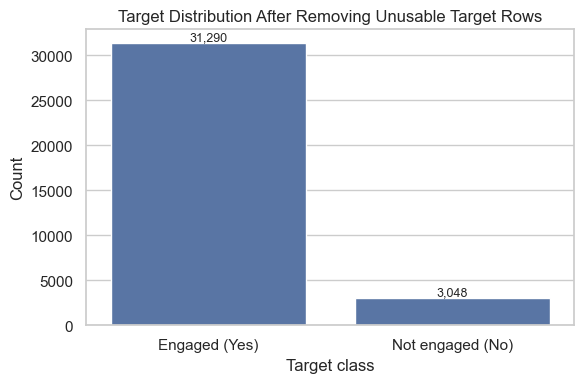

In [7]:
# Plot 1: Target distribution (class imbalance check)
plot_df = participation_eda.copy()
plot_df['target_label'] = map_labels(plot_df['target_binary'], 'target_binary')

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=plot_df, x='target_label', order=['Engaged (Yes)', 'Not engaged (No)'])
ax.set_title('Target Distribution After Removing Unusable Target Rows')
ax.set_xlabel('Target class')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=9)
save_fig('01_target_distribution.png')
plt.show()

Saved: evidence_codex/EDA_codex_Pics/02_feature_distributions.png


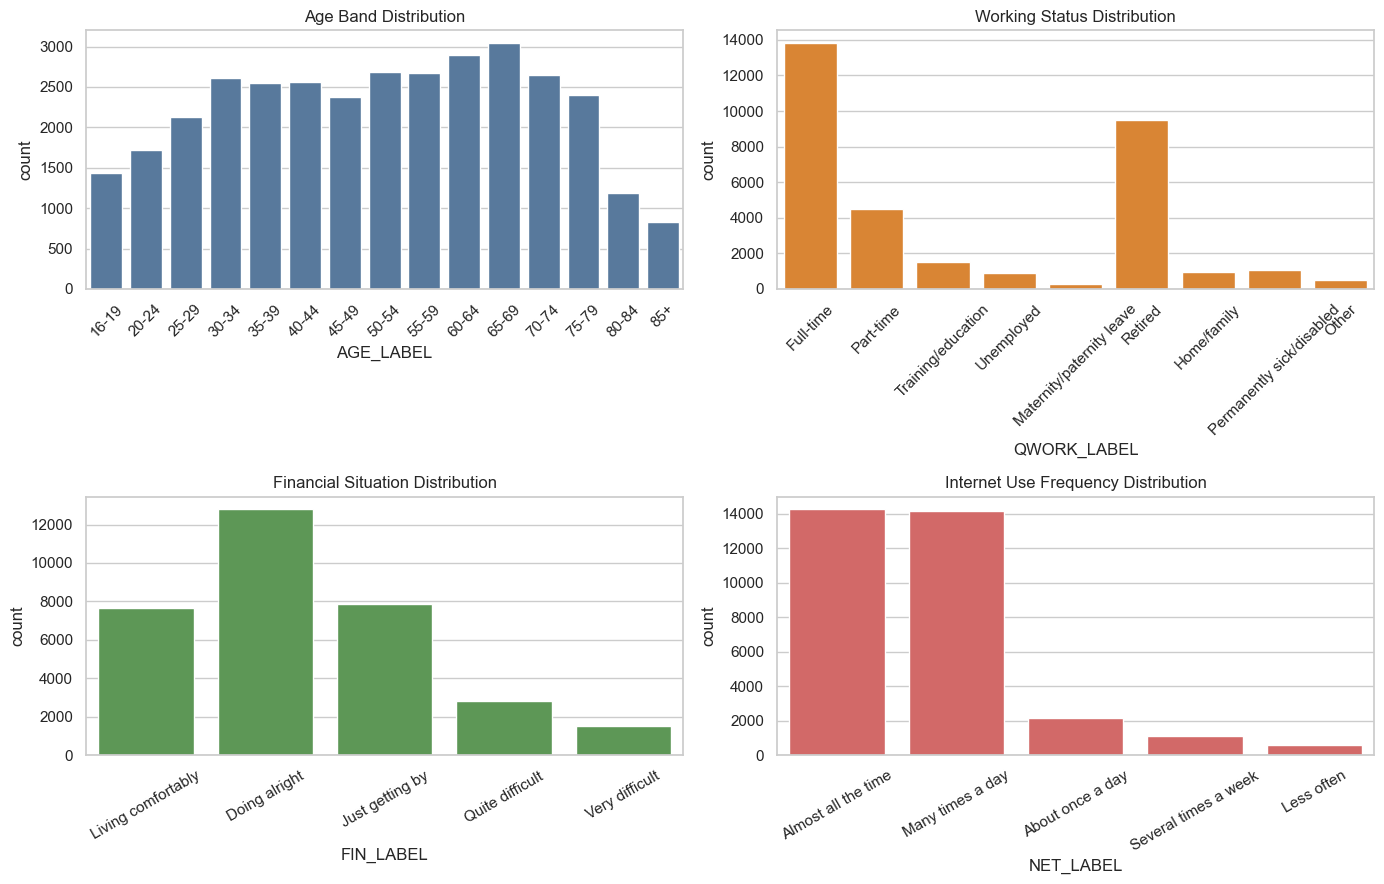

In [8]:
# Plot 2: Selected feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

age_order = [label_maps['AGEBAND'][k] for k in sorted(label_maps['AGEBAND'].keys())]
work_order = [label_maps['QWORK'][k] for k in [1, 2, 3, 4, 5, 6, 8, 9, 10]]

sns.countplot(data=plot_df.assign(AGE_LABEL=map_labels(plot_df['AGEBAND'], 'AGEBAND')),
              x='AGE_LABEL', order=age_order, ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set_title('Age Band Distribution')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=plot_df.assign(QWORK_LABEL=map_labels(plot_df['QWORK'], 'QWORK')),
              x='QWORK_LABEL', order=work_order, ax=axes[0, 1], color='#F58518')
axes[0, 1].set_title('Working Status Distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(data=plot_df.assign(FIN_LABEL=map_labels(plot_df['FINHARD'], 'FINHARD')),
              x='FIN_LABEL', order=[label_maps['FINHARD'][k] for k in [1,2,3,4,5]], ax=axes[1, 0], color='#54A24B')
axes[1, 0].set_title('Financial Situation Distribution')
axes[1, 0].tick_params(axis='x', rotation=30)

sns.countplot(data=plot_df.assign(NET_LABEL=map_labels(plot_df['CINTOFT'], 'CINTOFT')),
              x='NET_LABEL', order=[label_maps['CINTOFT'][k] for k in [1,2,3,4,5]], ax=axes[1, 1], color='#E45756')
axes[1, 1].set_title('Internet Use Frequency Distribution')
axes[1, 1].tick_params(axis='x', rotation=30)

save_fig('02_feature_distributions.png')
plt.show()

Saved: evidence_codex/EDA_codex_Pics/03_non_engagement_rates.png


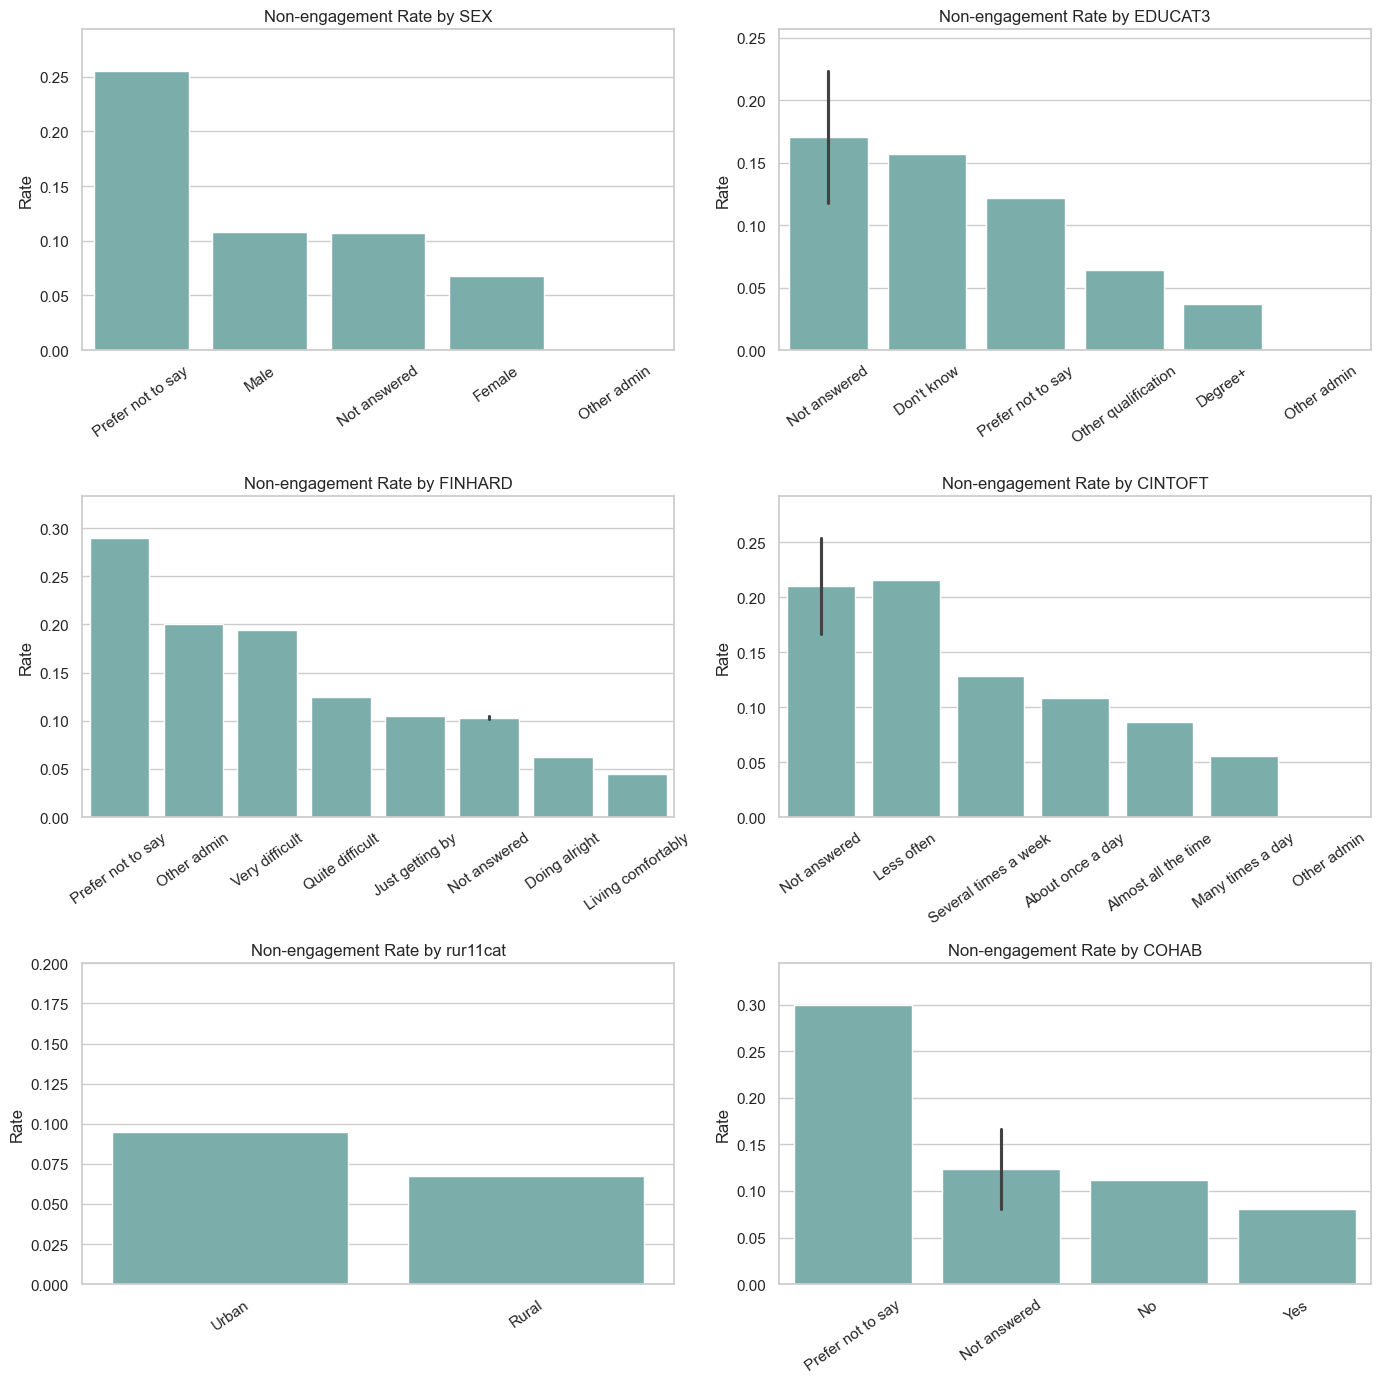

In [9]:
# Plot 3: Non-engagement rate by selected features
def non_engagement_rate(df, feature):
    tmp = (
        df.groupby(feature)['target_binary']
        .apply(lambda x: (x == 2).mean())
        .reset_index(name='non_engagement_rate')
    )
    tmp[feature] = map_labels(tmp[feature], feature)
    return tmp.sort_values('non_engagement_rate', ascending=False)

selected_features = ['SEX', 'EDUCAT3', 'FINHARD', 'CINTOFT', 'rur11cat', 'COHAB']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, feat in zip(axes, selected_features):
    rate_df = non_engagement_rate(participation_eda, feat)
    sns.barplot(data=rate_df, x=feat, y='non_engagement_rate', ax=ax, color='#72B7B2')
    ax.set_title(f'Non-engagement Rate by {feat}')
    ax.set_xlabel('')
    ax.set_ylabel('Rate')
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylim(0, max(0.2, rate_df['non_engagement_rate'].max() * 1.15))

save_fig('03_non_engagement_rates.png')
plt.show()

## 2.3 Key EDA insights for modelling
- The target is imbalanced: the non-engaged class (`CARTS_NET=2`) is the minority class, so model evaluation should not rely on accuracy alone.
- Several features include non-informative coded responses (for example, non-response/admin/prefer-not-to-say values), so variable-specific cleaning is needed before modelling.
- Non-engagement rates vary across socioeconomic and digital-access features, supporting the policy framing that under-engagement may be socially patterned.
- The distributions suggest all predictors should be treated as categorical in preprocessing, with robust handling for rare/unknown categories.

# 3 Missingness Handling
## 3.1 Rule definition
Feature missingness is coded via negative/admin codes (and some special codes like `997`/`999`) rather than `NaN`.

Handling rules (feature-specific):
- For each feature, convert non-informative codes to the category `Unknown`.
- Keep all rows to avoid unnecessary data loss, especially where non-response is common (for example `COHAB`).
- Preserve valid substantive codes as labelled categories.
- Ensure `participation_clean` has no missing values in feature columns and is ready for one-hot encoding.


In [10]:
# Variable-specific non-informative codes derived from dictionary meanings
feature_cols = ['AGEBAND', 'SEX', 'QWORK', 'EDUCAT3', 'FINHARD', 'CINTOFT', 'gor', 'rur11cat', 'CHILDHH', 'COHAB']

non_informative_codes = {
    'AGEBAND': {-3, 997},
    'SEX': {-5, -4, -3, 997},
    'QWORK': {-5, -4, -3, 997, 999},
    'EDUCAT3': {-5, -4, -3, 997, 999},
    'FINHARD': {-5, -4, -3, 997},
    'CINTOFT': {-5, -4, -3},
    'gor': set(),
    'rur11cat': set(),
    'CHILDHH': {-6, -5, -4, -3, 997},
    'COHAB': {-5, -4, -3, 997},
}

rows_before_cleaning = participation_eda.shape[0]
participation_clean = participation_eda.copy()

unknown_summary = []
for col in feature_cols:
    before_unknown = participation_clean[col].isin(non_informative_codes[col]).sum()

    # Replace non-informative codes with NaN, then map to labels and fill Unknown
    participation_clean.loc[participation_clean[col].isin(non_informative_codes[col]), col] = pd.NA

    # Map remaining valid codes to readable labels
    mapper = {k: v for k, v in label_maps[col].items() if k not in non_informative_codes[col]}
    participation_clean[col] = participation_clean[col].map(mapper)
    participation_clean[col] = participation_clean[col].fillna('Unknown').astype('string')

    after_unknown = (participation_clean[col] == 'Unknown').sum()
    unknown_summary.append({
        'feature': col,
        'rows_marked_unknown': int(after_unknown),
        'unknown_rate': float(after_unknown / rows_before_cleaning),
        'codes_treated_as_non_informative': sorted(non_informative_codes[col]),
    })

rows_after_cleaning = participation_clean.shape[0]
unknown_summary_df = pd.DataFrame(unknown_summary)

print(f'Rows before cleaning: {rows_before_cleaning}')
print(f'Rows after cleaning: {rows_after_cleaning}')
print(f'Rows dropped in Step 3: {rows_before_cleaning - rows_after_cleaning}')

print('\nUnknown-category summary by feature:')
display(unknown_summary_df)

# Validate readiness for modelling
feature_missing_counts = participation_clean[feature_cols].isna().sum()
print('\nMissing-value count per feature after cleaning:')
print(feature_missing_counts.to_string())
assert feature_missing_counts.sum() == 0, 'Feature missing values remain after cleaning.'

# Save cleaning audit table
unknown_summary_df.to_csv(evidence_dir / 'missingness_handling_summary.csv', index=False)
print('Saved:', evidence_dir / 'missingness_handling_summary.csv')

Rows before cleaning: 34338
Rows after cleaning: 34338
Rows dropped in Step 3: 0

Unknown-category summary by feature:


,feature,rows_marked_unknown,unknown_rate,codes_treated_as_non_informative
0,AGEBAND,606,0.017648,"[-3, 997]"
1,SEX,638,0.018580,"[-5, -4, -3, 997]"
2,QWORK,1364,0.039723,"[-5, -4, -3, 997, 999]"
3,EDUCAT3,8239,0.239938,"[-5, -4, -3, 997, 999]"
4,FINHARD,1652,0.048110,"[-5, -4, -3, 997]"
5,CINTOFT,2029,0.059089,"[-5, -4, -3]"
6,gor,0,0.000000,[]
7,rur11cat,0,0.000000,[]
8,CHILDHH,69,0.002009,"[-6, -5, -4, -3, 997]"
9,COHAB,24434,0.711573,"[-5, -4, -3, 997]"



Missing-value count per feature after cleaning:
AGEBAND     0
SEX         0
QWORK       0
EDUCAT3     0
FINHARD     0
CINTOFT     0
gor         0
rur11cat    0
CHILDHH     0
COHAB       0
Saved: evidence_codex/missingness_handling_summary.csv


# 4 Baseline Model Training + Evaluation Harness
## 4.1 Prepare modeling data
`X` and `y` are defined from `participation_clean`. The positive class is **under-engagement** (`target_binary == 2`) to align with the task objective.

All features are categorical and are one-hot encoded for both Logistic Regression and XGBoost. The same stratified split is used across models: 70% train, 15% validation, 15% test.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
from xgboost import XGBClassifier
import time
import itertools

# Define X and y
target_col = 'target_binary'
X = participation_clean[feature_cols].copy()
y = (participation_clean[target_col] == 2).astype(int)

# Preprocessing pipelines for both model families
preprocessor_lr = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols)]
)
preprocessor_xgb = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols)]
)

# Stratified 0.7 / 0.15 / 0.15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Split sizes:')
print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]:.1%})')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/X.shape[0]:.1%})')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]:.1%})')

print('\nUnder-engagement class share (y=1):')
print(f'Overall: {y.mean():.3f}')
print(f'Train: {y_train.mean():.3f}')
print(f'Validation: {y_val.mean():.3f}')
print(f'Test: {y_test.mean():.3f}')

Split sizes:
Train: 24036 (70.0%)
Validation: 5151 (15.0%)
Test: 5151 (15.0%)

Under-engagement class share (y=1):
Overall: 0.089
Train: 0.089
Validation: 0.089
Test: 0.089


## 4.2 Evaluation harness design
To compare models consistently under class imbalance, the harness reports:
- `Recall (Under-engaged)`: priority metric to reduce missed under-engaged cases
- `PR-AUC`: informative under class imbalance
- `F1`: balance between precision and recall
- `Balanced Accuracy`: averages sensitivity and specificity
- `ROC-AUC`, `Precision`, `Specificity`, and confusion-matrix counts for diagnostic context

For tuning and ranking, a weighted **priority score** is used:
`0.40*Recall + 0.25*PR-AUC + 0.20*F1 + 0.15*Balanced Accuracy`.
This emphasizes finding under-engaged respondents while still penalizing extreme false positives.

In [12]:
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall_under_engaged': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
        'specificity': (tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }
    metrics['priority_score'] = (
        0.40 * metrics['recall_under_engaged']
        + 0.25 * metrics['pr_auc']
        + 0.20 * metrics['f1']
        + 0.15 * metrics['balanced_accuracy']
    )
    return metrics

def evaluate_model(model_name, pipeline, X_eval, y_eval):
    y_prob = pipeline.predict_proba(X_eval)[:, 1]
    out = evaluate_predictions(y_eval, y_prob)
    out['model'] = model_name
    return out

## 4.3 Baseline model: Logistic Regression
Baseline Logistic Regression is trained on the training split only, with reasonable untuned defaults (`class_weight='balanced'`, `C=1.0`, `liblinear`).
Validation-set performance is reported using the predefined evaluation harness. The test set is not used here.

In [13]:
baseline_lr_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor_lr),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        solver='liblinear',
        C=1.0,
        class_weight='balanced'
    ))
])

baseline_lr_pipeline.fit(X_train, y_train)
baseline_lr_val_metrics = evaluate_model('Baseline Logistic Regression (val)', baseline_lr_pipeline, X_val, y_val)

baseline_lr_val_df = pd.DataFrame([baseline_lr_val_metrics]).drop(columns=['model'])
print('Validation results for baseline Logistic Regression:')
display(baseline_lr_val_df)

baseline_lr_val_df.to_csv(evidence_dir / 'baseline_lr_validation_metrics.csv', index=False)
print('Saved:', evidence_dir / 'baseline_lr_validation_metrics.csv')

Validation results for baseline Logistic Regression:


,accuracy,precision,recall_under_engaged,f1,balanced_accuracy,roc_auc,pr_auc,specificity,tn,fp,fn,tp,priority_score
0,0.729567,0.194517,0.652079,0.299648,0.694595,0.763279,0.251343,0.737111,3460,1234,159,298,0.487786


Saved: evidence_codex/baseline_lr_validation_metrics.csv


# 5 Improving Performance
## 5.1 Tune Logistic Regression (validation only)
The same split is reused. Hyperparameters are searched on the training set and selected using validation performance only.

In [14]:
lr_grid = {
    'C': [0.1, 0.5, 1.0, 2.0, 5.0],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced'],
}

lr_trials = []
lr_combinations = list(itertools.product(lr_grid['C'], lr_grid['penalty'], lr_grid['class_weight']))

for trial_id, (C, penalty, cw) in enumerate(lr_combinations, start=1):
    trial_pipeline = Pipeline(steps=[
        ('preprocess', preprocessor_lr),
        ('model', LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=2500,
            solver='liblinear',
            C=C,
            penalty=penalty,
            class_weight=cw,
        ))
    ])

    t0 = time.perf_counter()
    trial_pipeline.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    metrics = evaluate_model('lr_trial', trial_pipeline, X_val, y_val)
    lr_trials.append({
        'trial': trial_id,
        'C': C,
        'penalty': penalty,
        'class_weight': str(cw),
        'fit_time_sec': fit_time,
        **{k: v for k, v in metrics.items() if k != 'model'},
    })

lr_tuning_df = pd.DataFrame(lr_trials).sort_values('priority_score', ascending=False).reset_index(drop=True)
best_lr_row = lr_tuning_df.iloc[0]
best_lr_params = {
    'C': float(best_lr_row['C']),
    'penalty': best_lr_row['penalty'],
    'class_weight': None if best_lr_row['class_weight'] == 'None' else best_lr_row['class_weight'],
}

lr_tuning_summary = {
    'tuning_method': 'Manual grid search on validation set',
    'hyperparameters_searched': ['C', 'penalty', 'class_weight'],
    'search_space': lr_grid,
    'total_parameter_configurations': len(lr_combinations),
    'trial_count_completed': int(lr_tuning_df.shape[0]),
    'best_hyperparameters': best_lr_params,
    'best_validation_metrics': {
        'priority_score': float(best_lr_row['priority_score']),
        'recall_under_engaged': float(best_lr_row['recall_under_engaged']),
        'pr_auc': float(best_lr_row['pr_auc']),
        'f1': float(best_lr_row['f1']),
        'balanced_accuracy': float(best_lr_row['balanced_accuracy']),
        'roc_auc': float(best_lr_row['roc_auc']),
    },
}

print('Structured tuning summary: Logistic Regression')
print(lr_tuning_summary)
display(lr_tuning_df.head(10))

lr_tuning_df.to_csv(evidence_dir / 'lr_tuning_results.csv', index=False)
print('Saved:', evidence_dir / 'lr_tuning_results.csv')

Structured tuning summary: Logistic Regression
{'tuning_method': 'Manual grid search on validation set', 'hyperparameters_searched': ['C', 'penalty', 'class_weight'], 'search_space': {'C': [0.1, 0.5, 1.0, 2.0, 5.0], 'penalty': ['l1', 'l2'], 'class_weight': [None, 'balanced']}, 'total_parameter_configurations': 20, 'trial_count_completed': 20, 'best_hyperparameters': {'C': 1.0, 'penalty': 'l2', 'class_weight': 'balanced'}, 'best_validation_metrics': {'priority_score': 0.4877861862672848, 'recall_under_engaged': 0.6520787746170679, 'pr_auc': 0.2513432600751633, 'f1': 0.2996480643539467, 'balanced_accuracy': 0.6945949902058497, 'roc_auc': 0.7632792083380339}}


,trial,C,penalty,class_weight,fit_time_sec,accuracy,precision,recall_under_engaged,f1,balanced_accuracy,roc_auc,pr_auc,specificity,tn,fp,fn,tp,priority_score
0,12,1.0,l2,balanced,0.044450,0.729567,0.194517,0.652079,0.299648,0.694595,0.763279,0.251343,0.737111,3460,1234,159,298,0.487786
1,10,1.0,l1,balanced,0.660459,0.729955,0.194771,0.652079,0.299950,0.694808,0.763356,0.250705,0.737537,3462,1232,159,298,0.487719
2,8,0.5,l2,balanced,0.046890,0.729373,0.194390,0.652079,0.299497,0.694488,0.763328,0.251182,0.736898,3459,1235,159,298,0.487700
3,20,5.0,l2,balanced,0.050687,0.729761,0.194644,0.652079,0.299799,0.694702,0.763264,0.250650,0.737324,3461,1233,159,298,0.487659
4,18,5.0,l1,balanced,2.297572,0.729761,0.194644,0.652079,0.299799,0.694702,0.763277,0.250580,0.737324,3461,1233,159,298,0.487642
5,16,2.0,l2,balanced,0.046132,0.729567,0.194517,0.652079,0.299648,0.694595,0.763277,0.250642,0.737111,3460,1234,159,298,0.487611
6,14,2.0,l1,balanced,1.033846,0.729567,0.194517,0.652079,0.299648,0.694595,0.763301,0.250612,0.737111,3460,1234,159,298,0.487603
7,2,0.1,l1,balanced,0.246712,0.728402,0.193758,0.652079,0.298747,0.693956,0.763517,0.249745,0.735833,3454,1240,159,298,0.487111
8,6,0.5,l1,balanced,0.422899,0.729179,0.193864,0.649891,0.298643,0.693394,0.763421,0.250625,0.736898,3459,1235,160,297,0.486350
9,4,0.1,l2,balanced,0.043105,0.729179,0.193464,0.647702,0.297937,0.692407,0.763441,0.251278,0.737111,3460,1234,161,296,0.485349


Saved: evidence_codex/lr_tuning_results.csv


## 5.2 Train and tune XGBoost (validation only)
XGBoost is tuned on the same train/validation split, using the same evaluation harness and no test-set information.

In [15]:
xgb_grid = {
    'n_estimators': [120, 220],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_trials = []
xgb_combinations = list(itertools.product(
    xgb_grid['n_estimators'],
    xgb_grid['max_depth'],
    xgb_grid['learning_rate'],
    xgb_grid['min_child_weight'],
    xgb_grid['subsample'],
    xgb_grid['colsample_bytree'],
))

for trial_id, (n_est, max_depth, lr, min_child, subsample, colsample) in enumerate(xgb_combinations, start=1):
    trial_pipeline = Pipeline(steps=[
        ('preprocess', preprocessor_xgb),
        ('model', XGBClassifier(
            random_state=RANDOM_STATE,
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=n_est,
            max_depth=max_depth,
            learning_rate=lr,
            min_child_weight=min_child,
            subsample=subsample,
            colsample_bytree=colsample,
            reg_lambda=1.0,
            n_jobs=-1,
        ))
    ])

    t0 = time.perf_counter()
    trial_pipeline.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    metrics = evaluate_model('xgb_trial', trial_pipeline, X_val, y_val)
    xgb_trials.append({
        'trial': trial_id,
        'n_estimators': n_est,
        'max_depth': max_depth,
        'learning_rate': lr,
        'min_child_weight': min_child,
        'subsample': subsample,
        'colsample_bytree': colsample,
        'fit_time_sec': fit_time,
        **{k: v for k, v in metrics.items() if k != 'model'},
    })

xgb_tuning_df = pd.DataFrame(xgb_trials).sort_values('priority_score', ascending=False).reset_index(drop=True)
best_xgb_row = xgb_tuning_df.iloc[0]
best_xgb_params = {
    'n_estimators': int(best_xgb_row['n_estimators']),
    'max_depth': int(best_xgb_row['max_depth']),
    'learning_rate': float(best_xgb_row['learning_rate']),
    'min_child_weight': int(best_xgb_row['min_child_weight']),
    'subsample': float(best_xgb_row['subsample']),
    'colsample_bytree': float(best_xgb_row['colsample_bytree']),
    'reg_lambda': 1.0,
}

xgb_tuning_summary = {
    'tuning_method': 'Manual grid search on validation set',
    'hyperparameters_searched': list(xgb_grid.keys()),
    'search_space': xgb_grid,
    'total_parameter_configurations': len(xgb_combinations),
    'trial_count_completed': int(xgb_tuning_df.shape[0]),
    'best_hyperparameters': best_xgb_params,
    'best_validation_metrics': {
        'priority_score': float(best_xgb_row['priority_score']),
        'recall_under_engaged': float(best_xgb_row['recall_under_engaged']),
        'pr_auc': float(best_xgb_row['pr_auc']),
        'f1': float(best_xgb_row['f1']),
        'balanced_accuracy': float(best_xgb_row['balanced_accuracy']),
        'roc_auc': float(best_xgb_row['roc_auc']),
    },
}

print('Structured tuning summary: XGBoost')
print(xgb_tuning_summary)
display(xgb_tuning_df)

xgb_tuning_df.to_csv(evidence_dir / 'xgb_tuning_results.csv', index=False)
print('Saved:', evidence_dir / 'xgb_tuning_results.csv')

Structured tuning summary: XGBoost
{'tuning_method': 'Manual grid search on validation set', 'hyperparameters_searched': ['n_estimators', 'max_depth', 'learning_rate', 'min_child_weight', 'subsample', 'colsample_bytree'], 'search_space': {'n_estimators': [120, 220], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1], 'min_child_weight': [1], 'subsample': [0.8], 'colsample_bytree': [0.8]}, 'total_parameter_configurations': 8, 'trial_count_completed': 8, 'best_hyperparameters': {'n_estimators': 220, 'max_depth': 5, 'learning_rate': 0.05, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0}, 'best_validation_metrics': {'priority_score': 0.18613170838975152, 'recall_under_engaged': 0.061269146608315096, 'pr_auc': 0.24442778086208558, 'f1': 0.10748560460652591, 'balanced_accuracy': 0.5267998907306595, 'roc_auc': 0.7660496336400395}}


,trial,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,fit_time_sec,accuracy,precision,...,f1,balanced_accuracy,roc_auc,pr_auc,specificity,tn,fp,fn,tp,priority_score
0,7,220,5,0.05,1,0.8,0.8,0.388223,0.909726,0.437500,...,0.107486,0.526800,0.766050,0.244428,0.992331,4658,36,429,28,0.186132
1,8,220,5,0.10,1,0.8,0.8,0.303694,0.906038,0.341176,...,0.107011,0.525764,0.759228,0.235492,0.988070,4638,56,428,29,0.184523
2,6,220,3,0.10,1,0.8,0.8,0.336760,0.909338,0.419355,...,0.100193,0.524612,0.768514,0.246222,0.992331,4658,36,431,26,0.183043
3,4,120,5,0.10,1,0.8,0.8,0.189103,0.907979,0.380282,...,0.102273,0.524854,0.763052,0.240816,0.990626,4650,44,430,27,0.183019
4,5,220,3,0.05,1,0.8,0.8,0.211638,0.910891,0.479167,...,0.091089,0.522501,0.766633,0.247985,0.994674,4669,25,434,23,0.178721
5,2,120,3,0.10,1,0.8,0.8,0.134744,0.909532,0.411765,...,0.082677,0.519780,0.768151,0.248322,0.993609,4664,30,436,21,0.174964
6,3,120,5,0.05,1,0.8,0.8,0.192049,0.909920,0.425532,...,0.079365,0.519006,0.767396,0.245029,0.994248,4667,27,437,20,0.172487
7,1,120,3,0.05,1,0.8,0.8,0.255324,0.910503,0.437500,...,0.057260,0.513400,0.765591,0.245882,0.996165,4676,18,443,14,0.162186


Saved: evidence_codex/xgb_tuning_results.csv


## 5.3 Final test-set comparison (only after tuning)
After tuning is complete, the test set is used once for final comparison across:
1. Baseline Logistic Regression
2. Tuned Logistic Regression
3. Tuned XGBoost

Each model is refit on train+validation data before final testing.

In [16]:
# Combine train + validation for final model fitting
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

fit_times = {}

# Baseline LR (refit)
final_baseline_lr = Pipeline(steps=[
    ('preprocess', preprocessor_lr),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        solver='liblinear',
        C=1.0,
        class_weight='balanced'
    ))
])
t0 = time.perf_counter()
final_baseline_lr.fit(X_trainval, y_trainval)
fit_times['Baseline Logistic Regression'] = time.perf_counter() - t0

# Tuned LR (refit)
final_tuned_lr = Pipeline(steps=[
    ('preprocess', preprocessor_lr),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2500,
        solver='liblinear',
        C=best_lr_params['C'],
        penalty=best_lr_params['penalty'],
        class_weight=best_lr_params['class_weight'],
    ))
])
t0 = time.perf_counter()
final_tuned_lr.fit(X_trainval, y_trainval)
fit_times['Tuned Logistic Regression'] = time.perf_counter() - t0

# Tuned XGBoost (refit)
final_tuned_xgb = Pipeline(steps=[
    ('preprocess', preprocessor_xgb),
    ('model', XGBClassifier(
        random_state=RANDOM_STATE,
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=best_xgb_params['n_estimators'],
        max_depth=best_xgb_params['max_depth'],
        learning_rate=best_xgb_params['learning_rate'],
        min_child_weight=best_xgb_params['min_child_weight'],
        subsample=best_xgb_params['subsample'],
        colsample_bytree=best_xgb_params['colsample_bytree'],
        reg_lambda=best_xgb_params['reg_lambda'],
        n_jobs=-1,
    ))
])
t0 = time.perf_counter()
final_tuned_xgb.fit(X_trainval, y_trainval)
fit_times['Tuned XGBoost'] = time.perf_counter() - t0

# Test-set evaluation
comparison_rows = []
for model_name, model_obj in [
    ('Baseline Logistic Regression', final_baseline_lr),
    ('Tuned Logistic Regression', final_tuned_lr),
    ('Tuned XGBoost', final_tuned_xgb),
]:
    row = evaluate_model(model_name, model_obj, X_test, y_test)
    row['fit_time_sec'] = fit_times[model_name]
    comparison_rows.append(row)

test_comparison_df = pd.DataFrame(comparison_rows).sort_values('priority_score', ascending=False).reset_index(drop=True)
print('Final test-set comparison:')
display(test_comparison_df)

test_comparison_df.to_csv(evidence_dir / 'test_model_comparison.csv', index=False)
print('Saved:', evidence_dir / 'test_model_comparison.csv')

Final test-set comparison:


,accuracy,precision,recall_under_engaged,f1,balanced_accuracy,roc_auc,pr_auc,specificity,tn,fp,fn,tp,priority_score,model,fit_time_sec
0,0.741215,0.207219,0.678337,0.317460,0.712837,0.785734,0.287478,0.747337,3508,1186,147,310,0.513622,Baseline Logistic Regression,0.054684
1,0.741215,0.207219,0.678337,0.317460,0.712837,0.785734,0.287478,0.747337,3508,1186,147,310,0.513622,Tuned Logistic Regression,0.053484
2,0.912638,0.555556,0.076586,0.134615,0.535311,0.790116,0.304069,0.994035,4666,28,422,35,0.213871,Tuned XGBoost,0.317253


Saved: evidence_codex/test_model_comparison.csv


## 5.4 Final model decision framework
The final model is selected using a quantitative multi-dimensional framework:

- **Predictive effectiveness (75%)**:
  - Recall for under-engagement: 35%
  - PR-AUC: 20%
  - F1: 10%
  - Balanced Accuracy: 10%
- **Interpretability for policy communication (15%)**
- **Operational efficiency (training time) (10%)**

Interpretability scores are assigned on a 0-1 scale:
- Baseline Logistic Regression: 1.00
- Tuned Logistic Regression: 0.95
- Tuned XGBoost: 0.70

The top total score determines the final model.

In [17]:
interpretability_scores = {
    'Baseline Logistic Regression': 1.00,
    'Tuned Logistic Regression': 0.95,
    'Tuned XGBoost': 0.70,
}

selection_df = test_comparison_df.copy()
selection_df['interpretability_score'] = selection_df['model'].map(interpretability_scores)

# Convert fit time into an efficiency score in [0,1] (faster = higher)
max_time = selection_df['fit_time_sec'].max()
min_time = selection_df['fit_time_sec'].min()
if max_time == min_time:
    selection_df['efficiency_score'] = 1.0
else:
    selection_df['efficiency_score'] = (max_time - selection_df['fit_time_sec']) / (max_time - min_time)

selection_df['final_framework_score'] = (
    0.35 * selection_df['recall_under_engaged']
    + 0.20 * selection_df['pr_auc']
    + 0.10 * selection_df['f1']
    + 0.10 * selection_df['balanced_accuracy']
    + 0.15 * selection_df['interpretability_score']
    + 0.10 * selection_df['efficiency_score']
)

selection_df = selection_df.sort_values('final_framework_score', ascending=False).reset_index(drop=True)
final_model_choice = selection_df.loc[0, 'model']

print('Model selection framework results:')
display(selection_df[['model', 'final_framework_score', 'recall_under_engaged', 'pr_auc', 'f1', 'balanced_accuracy', 'interpretability_score', 'efficiency_score', 'fit_time_sec']])
print(f'Final selected model: {final_model_choice}')

selection_df.to_csv(evidence_dir / 'model_selection_framework.csv', index=False)
print('Saved:', evidence_dir / 'model_selection_framework.csv')

Model selection framework results:


,model,final_framework_score,recall_under_engaged,pr_auc,f1,balanced_accuracy,interpretability_score,efficiency_score,fit_time_sec
0,Baseline Logistic Regression,0.647488,0.678337,0.287478,0.317460,0.712837,1.00,0.995451,0.054684
1,Tuned Logistic Regression,0.640443,0.678337,0.287478,0.317460,0.712837,0.95,1.000000,0.053484
2,Tuned XGBoost,0.259612,0.076586,0.304069,0.134615,0.535311,0.70,0.000000,0.317253


Final selected model: Baseline Logistic Regression
Saved: evidence_codex/model_selection_framework.csv
